# An introduction to Finite Element Analsysis (FEA) - 2D plate example

## Finite element analysis procedure

1. **Define the Geometry:**
   - Specify the geometry of the problem and discretise it into nodes.
   - Choose appropriate elements for the discretisation, e.g., triangular elements.
2. **Material Properties:**
   - Define the material properties of the material, as an example, for a linear elastic material the Young's modulus ($E$) and Poisson's ratio ($\nu$) must be defined.
3. **Mesh Generation:**
   - Create a mesh using the specified nodes and elements.
   - Tools like Delaunay triangulation can be used for mesh generation.
4. **Element Stiffness Matrix:**
   - Develop the local stiffness matrix for each triangular element.
   - Incorporate material properties and element geometry into the formulation.
5. **Assemble Global Stiffness Matrix:**
   - Assemble the global stiffness matrix by summing contributions from individual elements.
   - Account for boundary conditions during assembly.
6. **Apply Boundary Conditions:**
   - Set up and apply boundary conditions to the global stiffness matrix.
   - This may involve fixing certain degrees of freedom or applying prescribed displacements.
7. **Apply Loads:**
   - Apply external loads to the system by modifying the right-hand side of the equilibrium equation.
8. **Solve Linear System:**
   - Solve the linear system of equations using numerical methods (e.g., direct solvers or iterative methods).
   - The solution provides the nodal displacements.
9. **Post-Processing:**
   - Calculate and visualise additional quantities of interest, such as stresses, strains, and reactions.
   - Evaluate the results at specific points or along element edges.

### Element (Local) stiffness matrix

Creating the local stiffness matrix for a triangular element involves several steps.

1. **Shape Functions:**
   - Start by generating the shape functions for the triangular element. These shape functions $(N_1, \; N_2, \; N_3)$ describe how the field variable (e.g., displacement) varies across the element.
2. **Derivative of Shape Functions:**
   - Compute the derivatives of the shape functions $(\frac{\partial N_i}{\partial x}, \frac{\partial N_i}{\partial y})$ with respect to the natural coordinates $(\xi, \; \eta)$. These derivatives are required for mapping from natural coordinates to physical coordinates.
3. **Jacobian Matrix:**
   - Construct the Jacobian matrix $(J)$ using the derivatives of the shape functions and the nodal coordinates. The Jacobian matrix relates the derivatives of the shape functions in natural coordinates to the derivatives in physical coordinates.
4. **Inverse of Jacobian:**
   - Calculate the inverse of the Jacobian matrix $(J^{-1})$. This is needed to transform the derivatives of the shape functions from physical coordinates to natural coordinates.
5. **B Matrix (Strain-Displacement Matrix):**
   - Using the inverse Jacobian, construct the B matrix $(B)$ for the triangular element. The B matrix relates the strain at a point to the nodal displacements and is given by:
     $$B = \begin{bmatrix}
              \frac{\partial N_1}{\partial x} & 0 & \frac{\partial N_2}{\partial x} & 0 & \frac{\partial N_3}{\partial x} & 0 \\
              0 & \frac{\partial N_1}{\partial y} & 0 & \frac{\partial N_2}{\partial y} & 0 & \frac{\partial N_3}{\partial y} \\
              \frac{\partial N_1}{\partial y} & \frac{\partial N_1}{\partial x} & \frac{\partial N_2}{\partial y} & \frac{\partial N_2}                {\partial x} & \frac{\partial N_3}{\partial y} & \frac{\partial N_3}{\partial x} \\
           \end{bmatrix}$$
6. **Material Stiffness Matrix:**
   - Define the material properties of the element, such as Young's modulus $(E)$ and Poisson's ratio $(v)$. Use these properties to compute the material stiffness matrix $(D)$.
7. **Element Stiffness Matrix:**
   - Combine the $B$ matrix and material stiffness matrix to obtain the local stiffness matrix $(K_{\text{local}})$ for the triangular element: $$K_{\text{local}} = t \cdot B^T \cdot D \cdot B \cdot \text{det}(J)$$
   - Here, $t$ is the element thickness, and $\text{det}(J)$ is the determinant of the Jacobian matrix.
8. **Assembly:**
   - Repeat the above steps for each element in the mesh to create local stiffness matrices $(K_{\text{local}}^1, \; K_{\text{local}}^2, \; \ldots \;)$
9. **Global Stiffness Matrix:**
   - Assemble the local stiffness matrices into the global stiffness matrix $(K_{\text{global}})$ based on the connectivity of nodes in the mesh.

The resulting global stiffness matrix is then used to solve the system of linear equations representing the equilibrium of the structure under applied loads and boundary conditions. The solution provides the nodal displacements and, consequently, the deformation of the structure.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

import fea

In [2]:
def build_nodes(dx, n_div_x, n_div_y):
    """
    Build nodes
    """
    nodes = np.zeros([n_div_x * n_div_y, 2])
    counter = 0

    for i_y in range(n_div_y):  # Depth
        for i_x in range(n_div_x):  # Length
            coord_x = dx * i_x
            coord_y = dx * i_y
            nodes[counter, 0] = coord_x
            nodes[counter, 1] = coord_y
            counter += 1

    return nodes

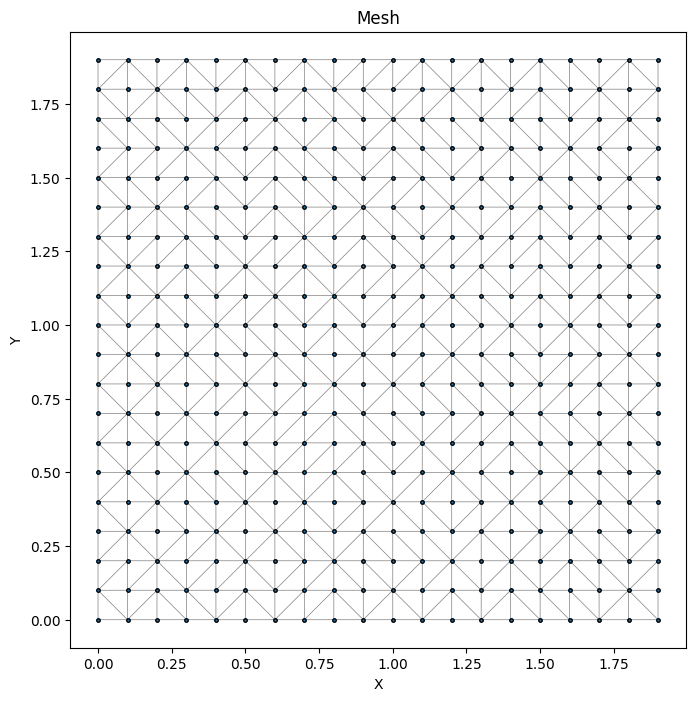

In [3]:
dx = 0.1
points = build_nodes(dx, 20, 20)
mesh = fea.Mesh(points)
mesh.plot()

In [10]:
print(mesh.elements[1].nodes)
print(mesh.elements[1].vertices)
print(mesh.elements[1].area)

[108 129 128]
[[0.8 0.5]
 [0.9 0.6]
 [0.8 0.6]]
0.005000000000000004


In [4]:
def build_boundary_conditions(particles, dx):
    bc_flag = np.zeros((len(particles), 2), dtype=np.intc)
    bc_unit_vector = np.zeros((len(particles), 2), dtype=np.intc)

    tol = 1e-6

    for i, particle in enumerate(particles):
        if particle[1] < (0.02 + tol):
            bc_flag[i, 1] = 1
            bc_unit_vector[i, 1] = -1
        if particle[1] > (0.18 - dx - tol):
            bc_flag[i, 1] = 1
            bc_unit_vector[i, 1] = 1

    return bc_flag, bc_unit_vector

In [5]:
boundary_conditions = build_boundary_conditions(points, dx)

In [6]:
# plate = fea.Model(mesh, boundary_conditions)

TypeError: GlobalStiffnessMatrix.__init__() takes 1 positional argument but 2 were given

## Gaussian Process Regression

1. Run 100+ simulations of a loaded 2D plate with variable dimensions and material parameters
2. Gaussian process regression
3. Predict the response of a 2D plate with quantified levels of uncertainty